# Fan Plot Data Visualization Tutorial

## Introduction

This notebook is a step-by-step guide to understanding and implementing a fan plot in your visualizations. A fan plot enhances a regular line plot by introducing a new dimension of data representation: the uncertainty of the line plot trend. By studying the width of a fan plot, the viewer can understand the variation in the data of our line plot. As discussed in Data Feminism by Catherine D'Ignazio and Lauren F. Klein, visualizations like a fan plot can help "visceralize" data by making patterns feel more meaningful and easier to interpret. In this project, the fan plot helps make the data's variation more visible by showing percentile bands around the central trend.

## Why a Fan Plot?


The reason I chose the fan plot is that Matplotlib's documentation mainly focuses on building different types of bar plots, line plots, and scatterplots, where visualizations like the fan plot are usually not well-known, even when they show the uncertainty/variation in our data over a period of time for our line plot. The simple, effective nature, along with the lack of documentation in matplotlib, motivates me to create this tutorial that guides users through a step-by-step process to build their own fan plot.

Also, according to Cairo, a visualization like the fan plot is highly valuable for a project, as it clearly shows data patterns without oversimplifying. It also relates to the teachings of Edward Tufte, which state that a good plot conveys rich information efficiently, similar to what a fan plot does. 


## Dataset

For this project, we will be using a publicly accessible dataset from the NASA Goddard Institute for Space Studies, GISTEMP v4.

**URL used in this notebook:** `https://data.giss.nasa.gov/gistemp/tabledata_v4/GLB.Ts+dSST.csv`

**Website page link:** `https://data.giss.nasa.gov/gistemp/data_v4.html`


## Packages needed

For this tutorial, we will only be using the basic python packages that are readily available on majority of the systems without an pre-required conditions.

**The packages that we will need are:**    `Matplotlib.pyplot`, `Pandas`, `Numpy`

In [7]:
import matplotlib.pyplot as plt 
import pandas as pd 
import numpy as np

## Tutorial 

###   First we will import and clean the dataset that we will be using for this tutorial

In [8]:
dat_fan = pd.read_csv("GLB.Ts+dSST.csv",skiprows=1)
#display(dat_fan)
dat_fan.columns

Index(['Year', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep',
       'Oct', 'Nov', 'Dec', 'J-D', 'D-N', 'DJF', 'MAM', 'JJA', 'SON'],
      dtype='object')

In [13]:
dat_fan = dat_fan[["Year", "J-D"]]
dat_fan_2 = dat_fan.dropna()
dat_fan_2 = dat_fan_2.rename(columns={"J-D": "Annual_Anomaly_C"})
dat_fan_2["Annual_Anomaly_C"] = pd.to_numeric(dat_fan_2["Annual_Anomaly_C"], errors="coerce")
display(dat_fan_2)

,Year,Annual_Anomaly_C
0,1880,-0.17
1,1881,-0.08
2,1882,-0.11
3,1883,-0.17
4,1884,-0.28
...,...,...
142,2022,0.89
143,2023,1.17
144,2024,1.28
145,2025,1.19


### From here we will build the base line plot of our data that we will show the variation in through the fan plot

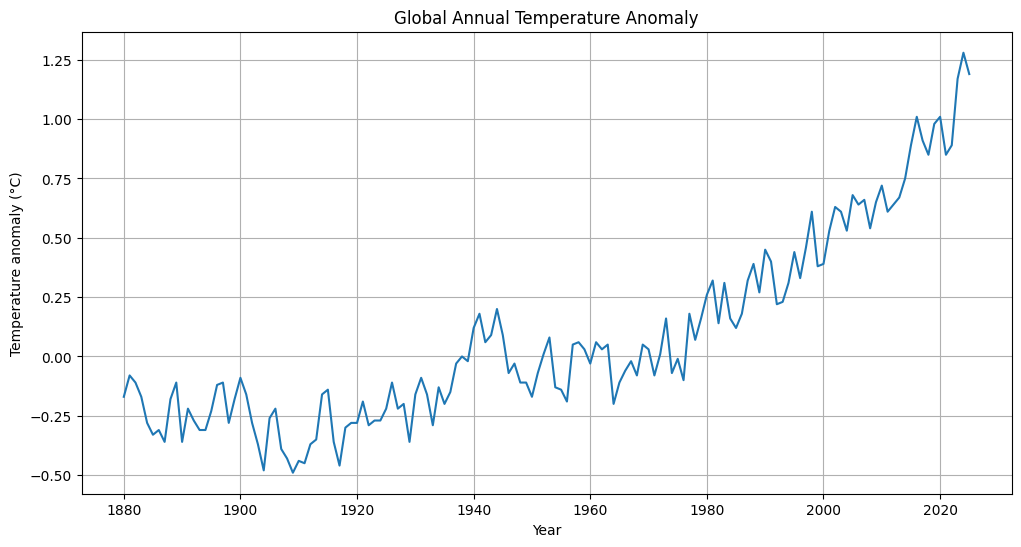

In [14]:

plt.figure(figsize=(12, 6))
plt.plot(dat_fan_2["Year"],dat_fan_2["Annual_Anomaly_C"])
plt.title("Global Annual Temperature Anomaly")
plt.xlabel("Year")
plt.ylabel("Temperature anomaly (°C)")
plt.grid()


### After making your base line plot, we will now try to find the median and the percentile values to make the ranges of our line plot around the central median.

The function that we will be using to do this is `pandas.DataFrame.rolling` function that allows us to provide the window of calculation, in this case 30 years. This means that for each year, Python looks at a 30-year range of temperature anomaly values and calculates different percentiles within that window.

The 50th percentile here will be the rolling median, the 25th-75th and the 10th-90th percentile will show the variation in the line plot and the spread of uncertainty.

In [11]:

dat_fan_2["p10"] = dat_fan_2["Annual_Anomaly_C"].rolling(window=30, center=True, min_periods=1).quantile(0.10)
dat_fan_2["p25"] = dat_fan_2["Annual_Anomaly_C"].rolling(window=30, center=True, min_periods=1).quantile(0.25)
dat_fan_2["p50"] = dat_fan_2["Annual_Anomaly_C"].rolling(window=30, center=True, min_periods=1).quantile(0.50)
dat_fan_2["p75"] = dat_fan_2["Annual_Anomaly_C"].rolling(window=30, center=True, min_periods=1).quantile(0.75)
dat_fan_2["p90"] = dat_fan_2["Annual_Anomaly_C"].rolling(window=30, center=True, min_periods=1).quantile(0.90)

display(dat_fan_2)

,Year,Annual_Anomaly_C,p10,p25,p50,p75,p90
0,1880,-0.17,-0.348,-0.3100,-0.270,-0.1700,-0.110
1,1881,-0.08,-0.345,-0.3100,-0.250,-0.1700,-0.110
2,1882,-0.11,-0.342,-0.3100,-0.230,-0.1700,-0.110
3,1883,-0.17,-0.339,-0.3100,-0.225,-0.1325,-0.110
4,1884,-0.28,-0.336,-0.3100,-0.230,-0.1450,-0.110
...,...,...,...,...,...,...,...
142,2022,0.89,0.634,0.6650,0.850,0.9950,1.174
143,2023,1.17,0.631,0.6825,0.870,1.0025,1.176
144,2024,1.28,0.646,0.7200,0.890,1.0100,1.178
145,2025,1.19,0.655,0.7425,0.890,1.0100,1.180


### Plotting our visualization



Now with the required data, in order to make our fan plot, we will utilize a mtplotlib function called `fill_between()`. This fuction will take in the inputs of lower and upper bounds along the x axis and shade a band between these two bounds.

```python
plt.fill_between(x, lower_bound, upper_bound)
```

This will give us our distinct fan plot look and help us study the uncertainty in our measurement of the line plot trend.



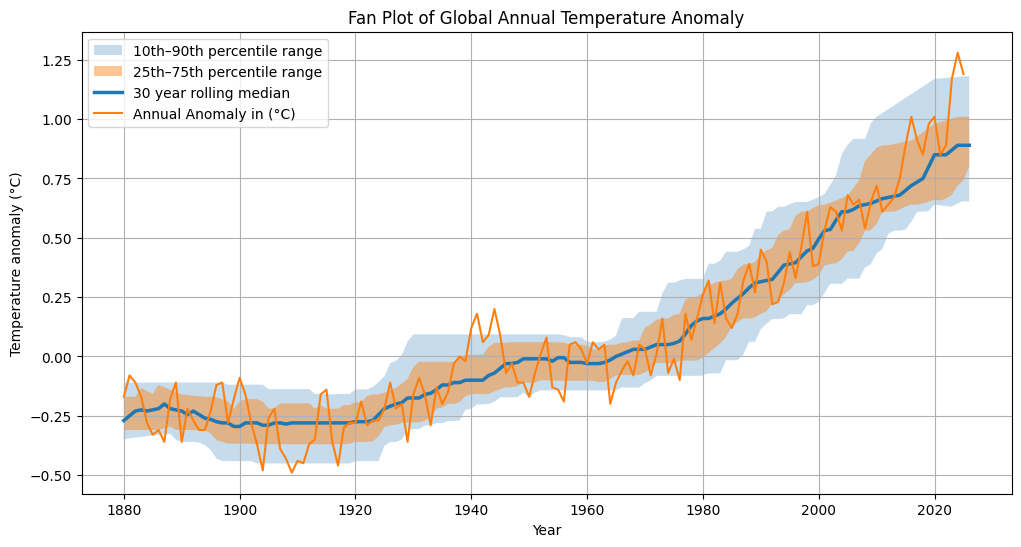

In [12]:
plt.figure(figsize=(12,6))

plt.fill_between(dat_fan_2["Year"],dat_fan_2["p10"],dat_fan_2["p90"],alpha=0.25,label="10th–90th percentile range")
plt.fill_between(dat_fan_2["Year"],dat_fan_2["p25"],dat_fan_2["p75"],alpha=0.45,label="25th–75th percentile range")


plt.plot(dat_fan_2["Year"],dat_fan_2["p50"],linewidth=2.5,label="30 year rolling median")
plt.plot(dat_fan_2["Year"],dat_fan_2["Annual_Anomaly_C"],label="Annual Anomaly in (°C)")
plt.title("Fan Plot of Global Annual Temperature Anomaly")
plt.xlabel("Year")
plt.ylabel("Temperature anomaly (°C)")
plt.legend()
plt.grid()

## Conclusion

The simplicity of a fan plot, combined with its minimal need for new data, already makes it a strong tool for data visualization. When representing data with multiple y values for a single x value, the fan plot can be used to visualize the data's statistics, such as percentile cut-offs and the median value, directly on the graph. This is extremely helpful in the research setting, where you are working on projects simulating background neutrino counts and need to know the distribution of your simulations. 

The ease of use and wide variety of applications make this fan plot important, and with the help of this tutorial, anyone can implement it in their work.


